#Task 1

In [2]:
import pandas as pd
import numpy as np
import matplotlib . pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder,OneHotEncoder
from sklearn.preprocessing import MinMaxScaler,StandardScaler


file_path = "/content/titanic.csv"
df = pd.read_csv(file_path)

df.head(10)

print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nDataTypes: {df.dtypes}")

num_cols = df.select_dtypes(include=['number']).columns.tolist()
print(f"Numerical Columns: {num_cols}")

cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical Columns: {cat_cols}")

average = df["Fare"].mean()
print(f"Mean fare: {average}")

higher_average_salary = df[df['Fare'] > average]
print("\n===========================")
print(higher_average_salary['Name'].values)
print("\n===========================")

missing_percentages = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print(missing_percentages)



Shape: (891, 12)

Columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

DataTypes: PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object
Numerical Columns: ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
Categorical Columns: ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']
Mean fare: 32.204207968574636

['Cumings, Mrs. John Bradley (Florence Briggs Thayer)'
 'Futrelle, Mrs. Jacques Heath (Lily May Peel)' 'McCarthy, Mr. Timothy J'
 'Sloper, Mr. William Thompson' 'Fortune, Mr. Charles Alexander'
 'Spencer, Mrs. William Augustus (Marie Eugenie)'
 'Meyer, Mr. Edgar Joseph' 'Holverson, Mr. Alexander Oskar'
 'Laroche, Miss. Simonne Marie Anne Andree' 'Panula, Master. 

#Task 2

In [3]:
df.drop(columns=['Cabin'])
age_median = df['Age'].median()
df['Age'] = df['Age'].fillna(age_median)
print ( f" Missing in Age after imputation : {df['Age'].isnull ().sum ()}")


embarked_mode = df ['Embarked']. mode () [0]
print ( f" Most common port : { embarked_mode }")
df ['Embarked'] = df ['Embarked']. fillna ( embarked_mode )
print ( f" Missing in Embarked after imputation : {df[ 'Embarked']. isnull ().sum ()}")




 Missing in Age after imputation : 0
 Most common port : S
 Missing in Embarked after imputation : 0


#Task 3

In [4]:
le = LabelEncoder ()
df ['Sex_encoded'] = le . fit_transform ( df ['Sex'])

print(" Classes :", le.classes_ )
print( df[[ 'Sex', 'Sex_encoded']]. head () )

embarked_dummies = pd.get_dummies (df ['Embarked'] ,prefix ='Embarked', drop_first = True )
print( embarked_dummies . head () )

minmax = MinMaxScaler ()
df [[ 'Age_minmax', 'Fare_minmax']] = minmax.fit_transform ( df [[ 'Age', 'Fare']])
print (df[[ 'Age', 'Age_minmax', 'Fare', 'Fare_minmax']]. head () )



 Classes : ['female' 'male']
      Sex  Sex_encoded
0    male            1
1  female            0
2  female            0
3  female            0
4    male            1
   Embarked_Q  Embarked_S
0       False        True
1       False       False
2       False        True
3       False        True
4       False        True
    Age  Age_minmax     Fare  Fare_minmax
0  22.0    0.271174   7.2500     0.014151
1  38.0    0.472229  71.2833     0.139136
2  26.0    0.321438   7.9250     0.015469
3  35.0    0.434531  53.1000     0.103644
4  35.0    0.434531   8.0500     0.015713


#Task 4(a)

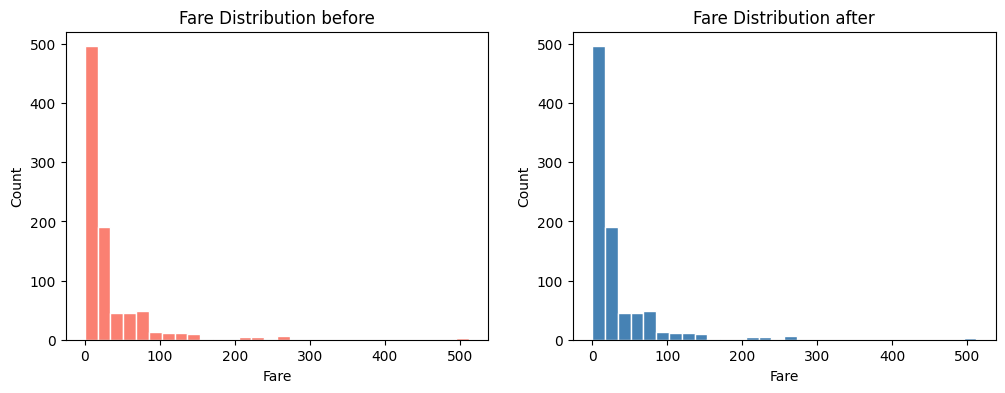

In [5]:
df_raw = pd.read_csv(file_path)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_raw['Fare'], bins=30, color='salmon', edgecolor='white')
axes[0].set_title("Fare Distribution before")
axes[0].set_xlabel("Fare")
axes[0].set_ylabel("Count")

axes[1].hist(df['Fare'], bins=30, color='steelblue', edgecolor='white')
axes[1].set_title("Fare Distribution after")
axes[1].set_xlabel("Fare")
axes[1].set_ylabel("Count")

plt.show()


#Task 4(b)

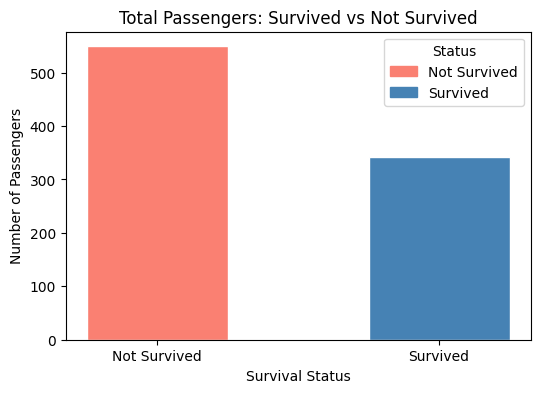

In [6]:
survival_counts = df['Survived'].value_counts().sort_index()

plt.figure(figsize=(6, 4))
bars = plt.bar(['Not Survived', 'Survived'],survival_counts.values,
    color=['salmon', 'steelblue'],edgecolor='white',width=0.5)



plt.title("Total Passengers: Survived vs Not Survived")
plt.xlabel("Survival Status")
plt.ylabel("Number of Passengers")
plt.legend(
    handles=[
        plt.Rectangle((0,0),1,1, color='salmon', label='Not Survived'),
        plt.Rectangle((0,0),1,1, color='steelblue', label='Survived')
    ],
    title="Status"
)

plt.show()

#Task 4(c)

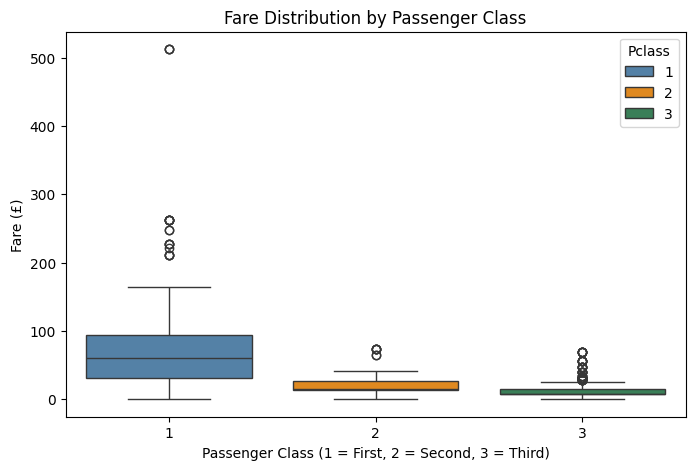

Median Fare by Passenger Class:
Pclass
1    60.2875
2    14.2500
3     8.0500
Name: Fare, dtype: float64

Class 1 has the highest median fare

Outlier count per class:
  Class 1: 20 outliers
  Class 2: 7 outliers
  Class 3: 52 outliers


In [7]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='Pclass',
    y='Fare',
    hue='Pclass',
    palette={1: 'steelblue', 2: 'darkorange', 3: 'seagreen'},
    legend=True
)

plt.title("Fare Distribution by Passenger Class")
plt.xlabel("Passenger Class (1 = First, 2 = Second, 3 = Third)")
plt.ylabel("Fare (£)")

plt.show()


median_fare_by_class = df.groupby('Pclass')['Fare'].median()
print("Median Fare by Passenger Class:")
print(median_fare_by_class)
print(f"\nClass {median_fare_by_class.idxmax()} has the highest median fare")


print("\nOutlier count per class:")
for cls in [1, 2, 3]:
    fare_cls = df[df['Pclass'] == cls]['Fare']
    Q1, Q3 = fare_cls.quantile(0.25), fare_cls.quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((fare_cls < Q1 - 1.5*IQR) | (fare_cls > Q3 + 1.5*IQR)).sum()
    print(f"  Class {cls}: {n_out} outliers")

#Task 4(d)

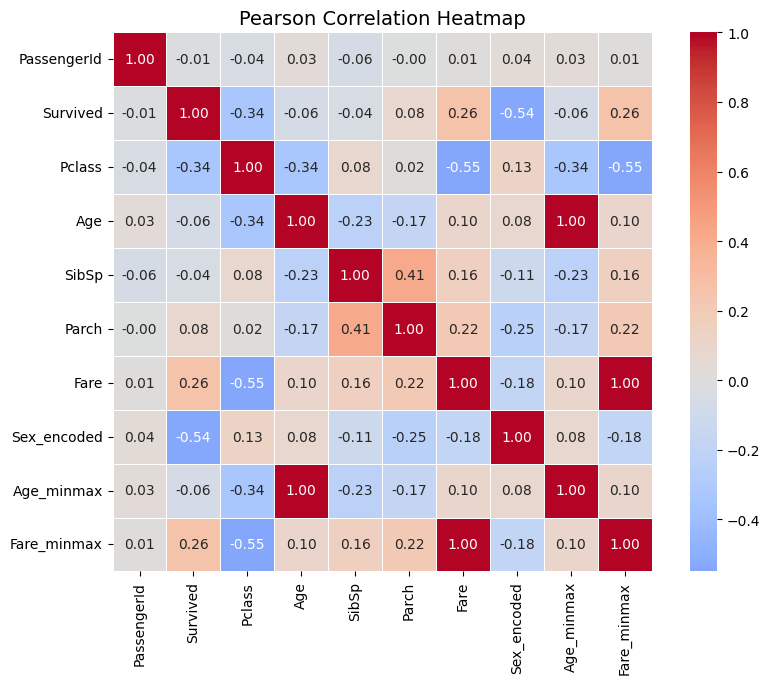

Top 3 features most correlated with Survived:
Sex_encoded    0.543351
Pclass         0.338481
Fare           0.257307


In [8]:
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(10, 7))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    square=True
)
plt.title("Pearson Correlation Heatmap", fontsize=14)
plt.show()

survived_corr = (
    corr_matrix['Survived']
    .drop('Survived')
    .abs()
    .sort_values(ascending=False)
)
print("Top 3 features most correlated with Survived:")
print(survived_corr.head(3).to_string())

#Task 4(e)

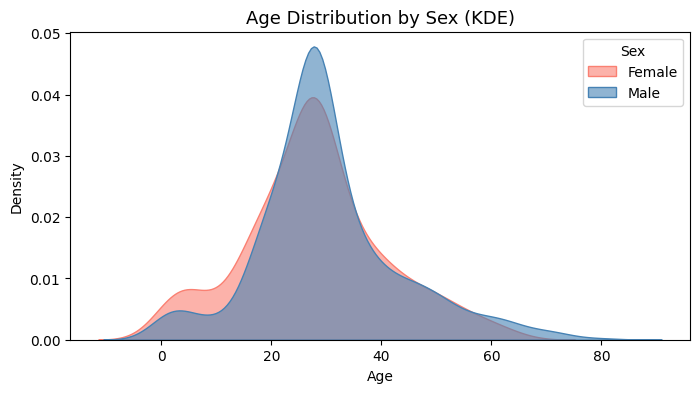

In [9]:
df_plot = df.copy()
df_plot['Sex'] = df_raw['Sex']

plt.figure(figsize=(8, 4))
sns.kdeplot(
    data=df_plot[df_plot['Sex'] == 'female'],
    x='Age',
    fill=True,
    color='salmon',
    label='Female',
    alpha=0.6
)
sns.kdeplot(
    data=df_plot[df_plot['Sex'] == 'male'],
    x='Age',
    fill=True,
    color='steelblue',
    label='Male',
    alpha=0.6
)

plt.title("Age Distribution by Sex (KDE)", fontsize=13)
plt.xlabel("Age")
plt.ylabel("Density")
plt.legend(title="Sex")
plt.show()

#Task 5

/tmp/ipykernel_13450/1817452381.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_13450/1817452381.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


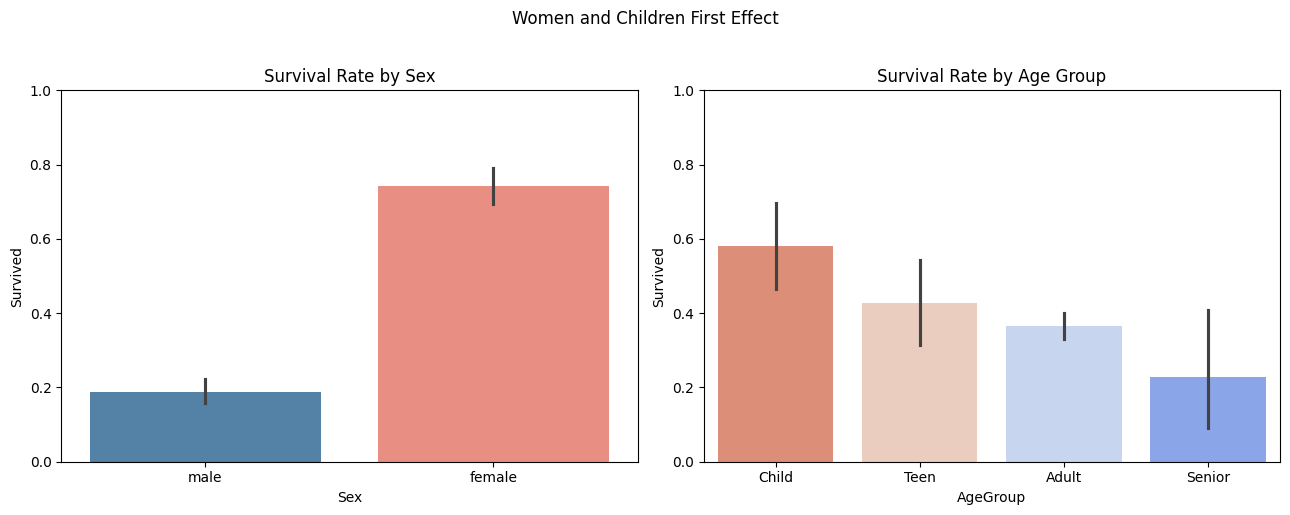

In [10]:
df_plot = df.copy()
df_plot['Sex'] = df_raw['Sex']

df_plot['AgeGroup'] = pd.cut(
    df_plot['Age'],
    bins=[0, 12, 18, 60, 100],
    labels=['Child', 'Teen', 'Adult', 'Senior']
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(
    data=df_plot,
    x='Sex',
    y='Survived',
    estimator='mean',
    palette={'female': 'salmon', 'male': 'steelblue'},
    ax=axes[0]
)

axes[0].set_title("Survival Rate by Sex")
axes[0].set_ylim(0, 1)


sns.barplot(
    data=df_plot,
    x='AgeGroup',
    y='Survived',
    estimator='mean',
    palette='coolwarm_r',
    ax=axes[1]
)

axes[1].set_title("Survival Rate by Age Group")
axes[1].set_ylim(0, 1)



plt.suptitle("Women and Children First Effect", y=1.02)
plt.tight_layout()
plt.show()